In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import datetime as dt
from scipy.optimize import minimize #what is this?
from scipy.stats import skew, kurtosis, shapiro
import seaborn as sns

In [2]:
#grabbing different assets with low correlation for a diversified portfolio
tickers = ['SPY', 'BND', 'GLD', 'QQQ', 'VTI']

In [3]:
#most recent date
end_date = dt.datetime.today()
print(end_date)

2025-07-28 16:23:51.743396


In [4]:
#start date (5 years ago)
start_date = end_date - dt.timedelta(days=5*365)
print(start_date)

2020-07-29 16:23:51.743396


In [5]:
#download for each ticker
adj_close_df = pd.DataFrame()
for ticker in tickers:
    data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False)
    adj_close_df[ticker] = data['Adj Close']

print(adj_close_df)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

                   SPY        BND         GLD         QQQ         VTI
Date                                                                 
2020-07-29  302.725098  77.272415  185.130005  252.248322  153.424225
2020-07-30  301.644958  77.315681  183.759995  253.568909  153.080276
2020-07-31  304.028656  77.419510  185.429993  258.093994  153.861130
2020-08-03  306.142273  77.392632  185.639999  261.580078  155.199692
2020-08-04  307.324799  77.557373  189.589996  262.551025  155.813187
...                ...        ...         ...         ...         ...
2025-07-22  628.859985  73.180000  316.100006  561.250000  309.799988
2025-07-23  634.210022  73.029999  312.179993  563.809998  312.410004
2025-07-24  634.419983  72.940002  310.269989  565.010010  312.299988
2025-07-25  637.099976  73.120003  307.399994  566.369995  313.690002
2025-07-28  636.940002  73.000000  305.410004  568.140015  313.600006

[1255 rows x 5 columns]


In [6]:
#changing to lognormal returns due to their additive property - look this up later!!
log_returns  = np.log(adj_close_df / adj_close_df.shift(1))

In [7]:
#drop any values
log_returns = log_returns.dropna()

In [8]:
print(log_returns)

                 SPY       BND       GLD       QQQ       VTI
Date                                                        
2020-07-30 -0.003574  0.000560 -0.007428  0.005222 -0.002244
2020-07-31  0.007871  0.001342  0.009047  0.017688  0.005088
2020-08-03  0.006928 -0.000347  0.001132  0.013417  0.008662
2020-08-04  0.003855  0.002126  0.021055  0.003705  0.003945
2020-08-05  0.006192 -0.001343  0.009240  0.002475  0.007252
...              ...       ...       ...       ...       ...
2025-07-22  0.000143  0.001641  0.009440 -0.005189  0.001163
2025-07-23  0.008472 -0.002052 -0.012479  0.004551  0.008390
2025-07-24  0.000331 -0.001233 -0.006137  0.002126 -0.000352
2025-07-25  0.004215  0.002465 -0.009293  0.002404  0.004441
2025-07-28 -0.000251 -0.001643 -0.006495  0.003120 -0.000287

[1254 rows x 5 columns]


ShapiroResult(statistic=np.float64(0.9884061457123912), pvalue=np.float64(2.0403003988795143e-08))


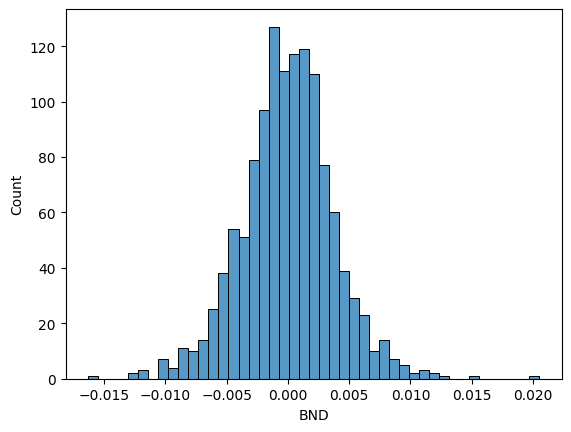

In [12]:
#looking at the distribution and its tails
#testing for normality - parametric or nonparametric test?
returns = log_returns['BND']
sns.histplot(returns)

#running Shapiro-Wilk test for normality
#This is a hypotheses test and the two hypotheses are as follows:

#Ho(Accepted): Sample is from the normal distributions.(Po>0.05)
#Ha(Rejected): Sample is not from the normal distributions.

#ok, but what are the tests for? Normally distributed can be useful for predicting future values? How do I do that?
shapiro_results = shapiro(returns)
print(shapiro_results)

#all returns are normally distributed (parametric)

In [13]:
#Calculate the covariance matrix
#This is how we are measuring the risk of the portfolio

cov_matrix = log_returns.cov()*252

In [14]:
print(cov_matrix)

          SPY       BND       GLD       QQQ       VTI
SPY  0.030568  0.001944  0.003728  0.038272  0.031041
BND  0.001944  0.003575  0.003114  0.002785  0.002035
GLD  0.003728  0.003114  0.023780  0.005004  0.003879
QQQ  0.038272  0.002785  0.005004  0.054401  0.038937
VTI  0.031041  0.002035  0.003879  0.038937  0.031853


In [15]:
#Defining Portfolio Metrics
#calculate the standard deviation
def standard_deviation(weights, cov_matrix):
    variance = weights.T @ cov_matrix @ weights
    return np.sqrt(variance)


In [16]:
#calculating expected return of the portfolio (prob * weight)
def expected_return(weights, log_returns):
    return np.sum(log_returns.mean()*weights)*252

In [17]:
#calclate the sharpe ratio
def sharpe_ratio(weights, log_returns, cov_matrix, risk_free_rate):
    return (expected_return(weights, log_returns)-risk_free_rate) / standard_deviation(weights, cov_matrix)

In [18]:
#how to get an accurate risk free rate?
#get fed's API
from fredapi import Fred

fred = Fred(api_key='c8a1a5229b19f852a4047fbc565554a7')

#GS10?? current treasury rate??
ten_year_treasury_rate = fred.get_series_latest_release('GS10')/100

risk_free_rate = ten_year_treasury_rate.iloc[-1]
print(risk_free_rate)

0.0438


In [19]:
#negative sharpe ratio
def neg_sharpe_ratio(weights, log_returns, cov_matrix, risk_free_rate):
    return -sharpe_ratio(weights, log_returns, cov_matrix, risk_free_rate)

In [20]:
#SETTING CONSTRAINTS AND BOUNDS

In [25]:
#set the constraints and bounds. Making sure weights equal to 1
#bounds - upper and lower. 0 lower, 0.5 upper
#0 means cant sell, 0.5 means we cant have anything over 50%

#({'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1}) 
#type: eq means equality, fun: means taking the array of portfolio weights as input and ensures all the weights equal to 1.
constraints = ({'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1})
bounds = [(0, 0.5) for _ in range(len(tickers))]

In [26]:
#set intital weights
initial_weights = np.array([1/len(tickers)]*(len(tickers)))
print(initial_weights)

#SLSQP stands for Sequential Least Squares Quadratic Programming, which is a numerical optimization technique suitable for solving nonlinear optimization problems with constraints.
#optimize the weights to maximize sharpe ratio but minimizing each weights needed that equal to 1
optimized_results = minimize(neg_sharpe_ratio, initial_weights, args=(log_returns, cov_matrix, risk_free_rate), method='SLSQP', constraints=constraints, bounds=bounds)

[0.2 0.2 0.2 0.2 0.2]


In [27]:
optimal_weights = optimized_results.x

print("Optimal Weights:")
for ticker, weight in zip(tickers, optimal_weights):
    print(f"{ticker}: {weight:.4f}")

optimal_portfolio_return = expected_return(optimal_weights, log_returns)
optimal_portfolio_volatility = standard_deviation(optimal_weights, cov_matrix)
optimal_sharpe_ratio = sharpe_ratio(optimal_weights, log_returns, cov_matrix, risk_free_rate)

print(f"Expected Annual Return: {optimal_portfolio_return:.4f}")
print(f"Expected Volatility: {optimal_portfolio_volatility:.4f}")
print(f"Sharpe Ratio: {optimal_sharpe_ratio:.4f}")

Optimal Weights:
SPY: 0.5000
BND: 0.0000
GLD: 0.4026
QQQ: 0.0000
VTI: 0.0974
Expected Annual Return: 0.1292
Expected Volatility: 0.1289
Sharpe Ratio: 0.6626


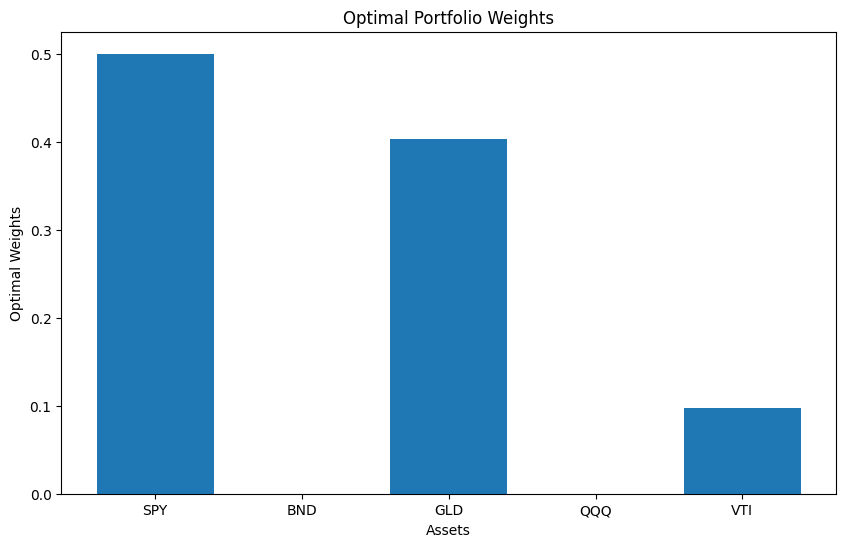

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(tickers, optimal_weights)

plt.xlabel('Assets')
plt.ylabel('Optimal Weights')
plt.title('Optimal Portfolio Weights')

plt.show()